# 01 — Training Data Generation

This notebook implements Phase 1: generate the dataset the surrogate will learn from.

**The single most important design decision in this project happens here, not in the
model.** For inverse design to be possible at all, the surrogate must be a function of
$(F, k)$ — it has to *know* the physics parameters, so that $\partial(\text{output})/\partial F$
exists. Concretely, every training sample carries its own $(F, k)$ alongside the state, and
later (Phase 2) the network's input will be `[U, V, F_grid, k_grid]` — F and k broadcast to
full grids and concatenated as extra channels. If a model were trained at one fixed $(F, k)$,
there would be nothing to take a gradient with respect to, and inverse design would be
impossible no matter how good the forward model was. It has to be designed in from here.

We sample $(F, k)$ across the same phase-space region mapped in notebook 00, from varied
random initial conditions, and save short contiguous trajectory windows — which support both
the single-step warm-up training and the multi-step rollout training in Phase 3 from one
generation pass (see `graydiff.data` docstring for why).

In [1]:
import json
import time

import matplotlib.pyplot as plt
import numpy as np

from graydiff.constants import F_RANGE, K_RANGE
from graydiff.data import GenerationConfig, generate_dataset, save_dataset, train_val_split_by_run
from graydiff.phase_classify import classify_pattern

plt.rcParams["figure.facecolor"] = "white"


## Generate the dataset

`window_len=10` means each run saves 11 consecutive solver states after a 2000-step warm-up
(long enough to move past the raw initial blob into representative mid-evolution dynamics —
notebook 00 used 10,000 steps to reach a fully-settled final pattern, but training data
benefits from seeing the system *while it's still developing*, not just its converged state,
since the surrogate must learn to predict transient dynamics too). With `n_runs=2000` that
gives `2000 * 10 = 20,000` single-step (state, F, k) -> next_state pairs, spanning phase space,
plus the same 2000 runs available as 10-step rollout-training trajectories.

In [2]:
config = GenerationConfig(
    n_runs=2000,
    grid_size=64,
    warmup_steps=2000,
    window_len=10,
    seed=0,
)

t0 = time.perf_counter()
data = generate_dataset(config)
t1 = time.perf_counter()
print(f"Generated {config.n_runs} runs ({config.n_runs * config.window_len} single-step pairs) in {t1-t0:.1f}s")
print("states shape:", data["states"].shape, data["states"].dtype)

save_dataset(data, "../data/raw/train_runs.npz")
import os
size_mb = os.path.getsize("../data/raw/train_runs.npz") / 1e6
print(f"Saved to data/raw/train_runs.npz ({size_mb:.1f} MB)")

Generated 2000 runs (20000 single-step pairs) in 205.3s
states shape: (2000, 11, 2, 64, 64) float32


Saved to data/raw/train_runs.npz (278.1 MB)


## EDA: phase-space coverage

Does the sampled $(F, k)$ set actually cover the region we care about, and roughly match the
regime proportions notebook 00 found? A lopsided sample (e.g. mostly "dead" runs) would waste
most of the dataset on uninformative examples.

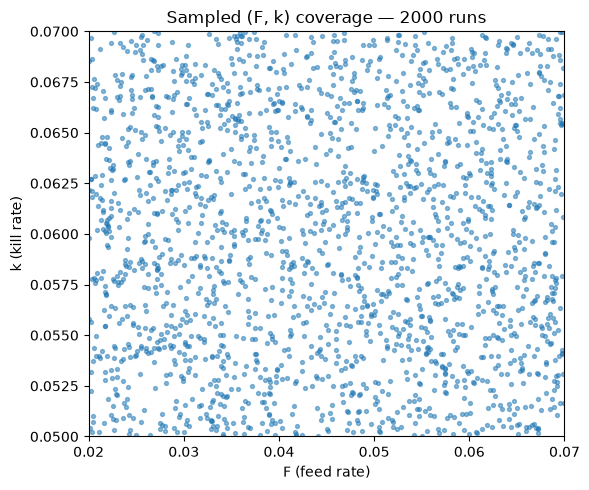

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(data["F"], data["k"], s=8, alpha=0.5)
ax.set_xlabel("F (feed rate)")
ax.set_ylabel("k (kill rate)")
ax.set_title(f"Sampled (F, k) coverage — {config.n_runs} runs")
ax.set_xlim(*F_RANGE)
ax.set_ylim(*K_RANGE)
plt.tight_layout()
plt.savefig("../figures/01_fk_coverage.png", dpi=110, bbox_inches="tight")
plt.show()

Pattern-type counts across generated runs (mid-transient state):
  uniform      716  (35.8%)
  mazes        549  (27.4%)
  dead         433  (21.6%)
  spots        269  (13.4%)
  stripes       33  (1.6%)


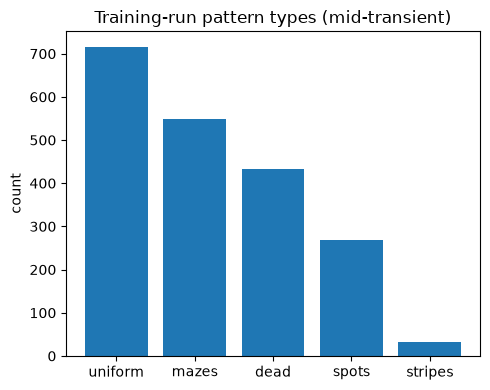

In [4]:
# Classify each run's LAST saved state (still mid-transient, not fully converged,
# but enough to see which regime it's heading toward) using notebook 00's classifier.
labels = [classify_pattern(data["states"][i, -1, 1]) for i in range(config.n_runs)]
from collections import Counter
counts = Counter(labels)
print("Pattern-type counts across generated runs (mid-transient state):")
for label, count in counts.most_common():
    print(f"  {label:10s} {count:5d}  ({100*count/config.n_runs:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(counts.keys(), counts.values())
ax.set_ylabel("count")
ax.set_title("Training-run pattern types (mid-transient)")
plt.tight_layout()
plt.savefig("../figures/01_pattern_type_histogram.png", dpi=110, bbox_inches="tight")
plt.show()

A meaningful chunk of "dead"/"uniform" runs mid-transient is expected and fine — some
sampled $(F,k)$ points genuinely do decay, and the surrogate needs to learn *that* dynamic
too (predicting decay correctly is as much a part of the physics as predicting spot formation).
What matters is that spots/stripes/mazes are all represented, not just one regime.

## EDA: does a single step look like a "small, sensible evolution"?

Spot-check a few random (state, F, k) -> next_state pairs. Two consecutive solver states
one step apart should look nearly identical — Phase 2's architecture will exploit exactly
this (predicting the small delta, not the whole next frame, is far more stable than
predicting the full state from scratch).

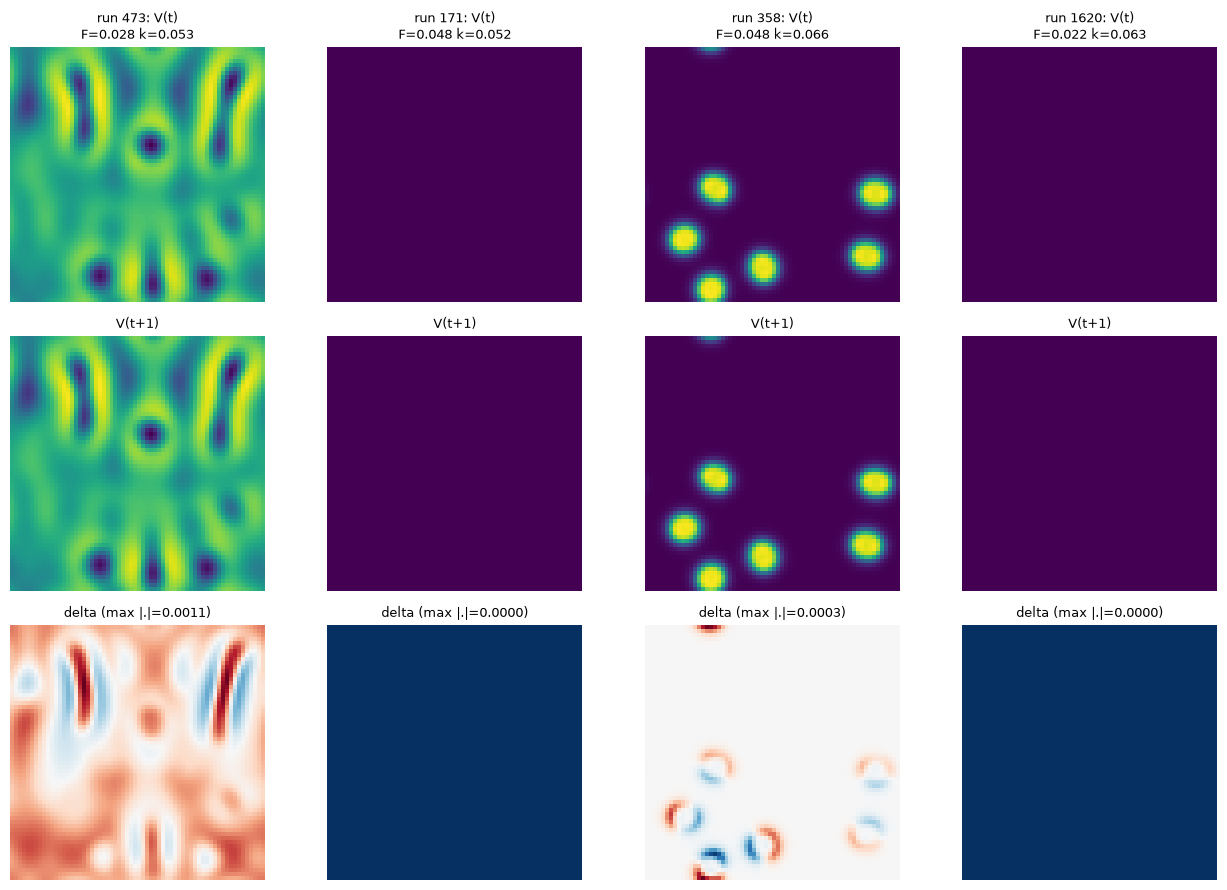

Max per-step |delta V| across the whole dataset: 0.014917135
This confirms the residual/delta the surrogate has to predict each step is small
relative to the state itself (V in [0,1]) -- motivating the residual architecture in Phase 2.


In [5]:
rng = np.random.default_rng(3)
sample_runs = rng.choice(config.n_runs, size=4, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(13, 9))
for col, run_idx in enumerate(sample_runs):
    t = rng.integers(0, config.window_len)
    state = data["states"][run_idx, t]
    next_state = data["states"][run_idx, t + 1]
    delta = next_state[1] - state[1]  # V-channel delta

    axes[0, col].imshow(state[1], cmap="viridis")
    axes[0, col].set_title(f"run {run_idx}: V(t)\nF={data['F'][run_idx]:.3f} k={data['k'][run_idx]:.3f}", fontsize=9)
    axes[1, col].imshow(next_state[1], cmap="viridis")
    axes[1, col].set_title("V(t+1)", fontsize=9)
    im = axes[2, col].imshow(delta, cmap="RdBu_r", vmin=-np.abs(delta).max(), vmax=np.abs(delta).max())
    axes[2, col].set_title(f"delta (max |.|={np.abs(delta).max():.4f})", fontsize=9)
    for row in range(3):
        axes[row, col].axis("off")
plt.tight_layout()
plt.savefig("../figures/01_single_step_examples.png", dpi=110, bbox_inches="tight")
plt.show()

print("Max per-step |delta V| across the whole dataset:",
      np.abs(np.diff(data['states'][:, :, 1], axis=1)).max())
print("This confirms the residual/delta the surrogate has to predict each step is small")
print("relative to the state itself (V in [0,1]) -- motivating the residual architecture in Phase 2.")

## Train / validation split by (F, k)

Phase 3 needs to validate on held-out $(F,k)$ *values*, not just held-out frames of the same
trajectories — otherwise "validation loss" would only prove the model memorized nearby frames
of runs it already saw, not that it generalizes across phase space. Splitting by RUN (not by
frame) achieves this for free: $F, k$ are drawn from a continuous distribution, so distinct
runs have distinct $(F, k)$ with probability 1.

train runs: 1700   val runs: 300


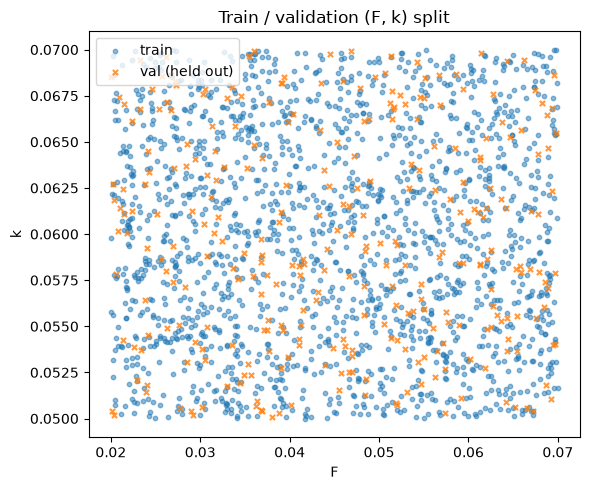

Saved data/raw/train_split.npz and data/raw/val_split.npz


In [6]:
train_data, val_data = train_val_split_by_run(data, val_frac=0.15, seed=0)
print(f"train runs: {train_data['F'].shape[0]}   val runs: {val_data['F'].shape[0]}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(train_data["F"], train_data["k"], s=10, alpha=0.5, label="train")
ax.scatter(val_data["F"], val_data["k"], s=14, alpha=0.8, label="val (held out)", marker="x")
ax.set_xlabel("F"); ax.set_ylabel("k")
ax.set_title("Train / validation (F, k) split")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/01_train_val_split.png", dpi=110, bbox_inches="tight")
plt.show()

save_dataset(train_data, "../data/raw/train_split.npz")
save_dataset(val_data, "../data/raw/val_split.npz")
print("Saved data/raw/train_split.npz and data/raw/val_split.npz")

## Summary

- Generated 2000 runs across the $(F, k)$ phase space (20,000 single-step pairs, plus the
  same runs usable as up-to-10-step rollout trajectories).
- Coverage spans the sampled region evenly; all major pattern regimes (spots/stripes/mazes/
  dead) are represented, not just one.
- Spot-checked single-step pairs confirm the per-step change is small relative to the state —
  the empirical justification for Phase 2's residual (predict-the-delta) architecture.
- Split by run into train/val so validation genuinely tests generalization across unseen
  physics parameters, not just unseen frames.

**Next:** notebook 02 builds the surrogate architecture — a small residual convnet with
circular padding, taking `[U, V, F_grid, k_grid]` as input.